# import

In [8]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import DensityMatrix
from qiskit.visualization import plot_state_city, plot_state_hinton, plot_state_qsphere

In [9]:
import sys
sys.path.append('../src')
from povm_sampling import *
from statesprep import *
from vae import *
from plots import *
from utils import *
from mle import *

# GHZ 3 qubit

# data

┌───┐          
q_0: ┤ H ├──■────■──
     └───┘┌─┴─┐  │  
q_1: ─────┤ X ├──┼──
          └───┘┌─┴─┐
q_2: ──────────┤ X ├
               └───┘

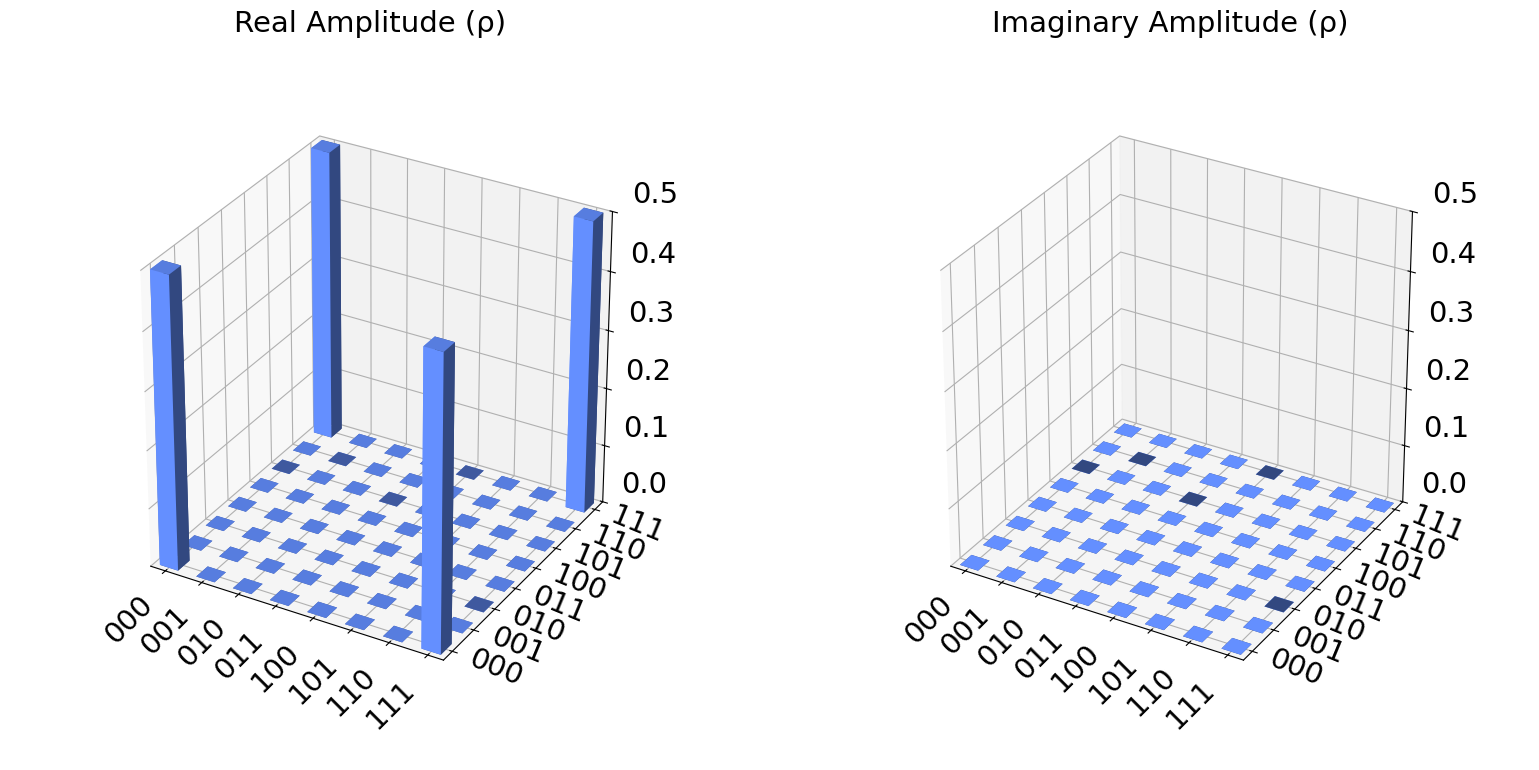

In [17]:
# true state circuit and density matrix
N = 3
qc = create_ghz_state(N)
display(qc.draw())

rho_true = DensityMatrix(qc)
fig = plot_state_city(rho_true)
display(fig)

In [ ]:
# create data sampling the true probability distribution
p_exact = povm_probability(rho_true.data, N)
samples = sample_povm(p_exact, 1000)

## direct reconstruction

  Hermitian:          True
  Tr(rho):            1.00000000
  Pos semi-definite:  False  (min eigval = -2.19e-01)


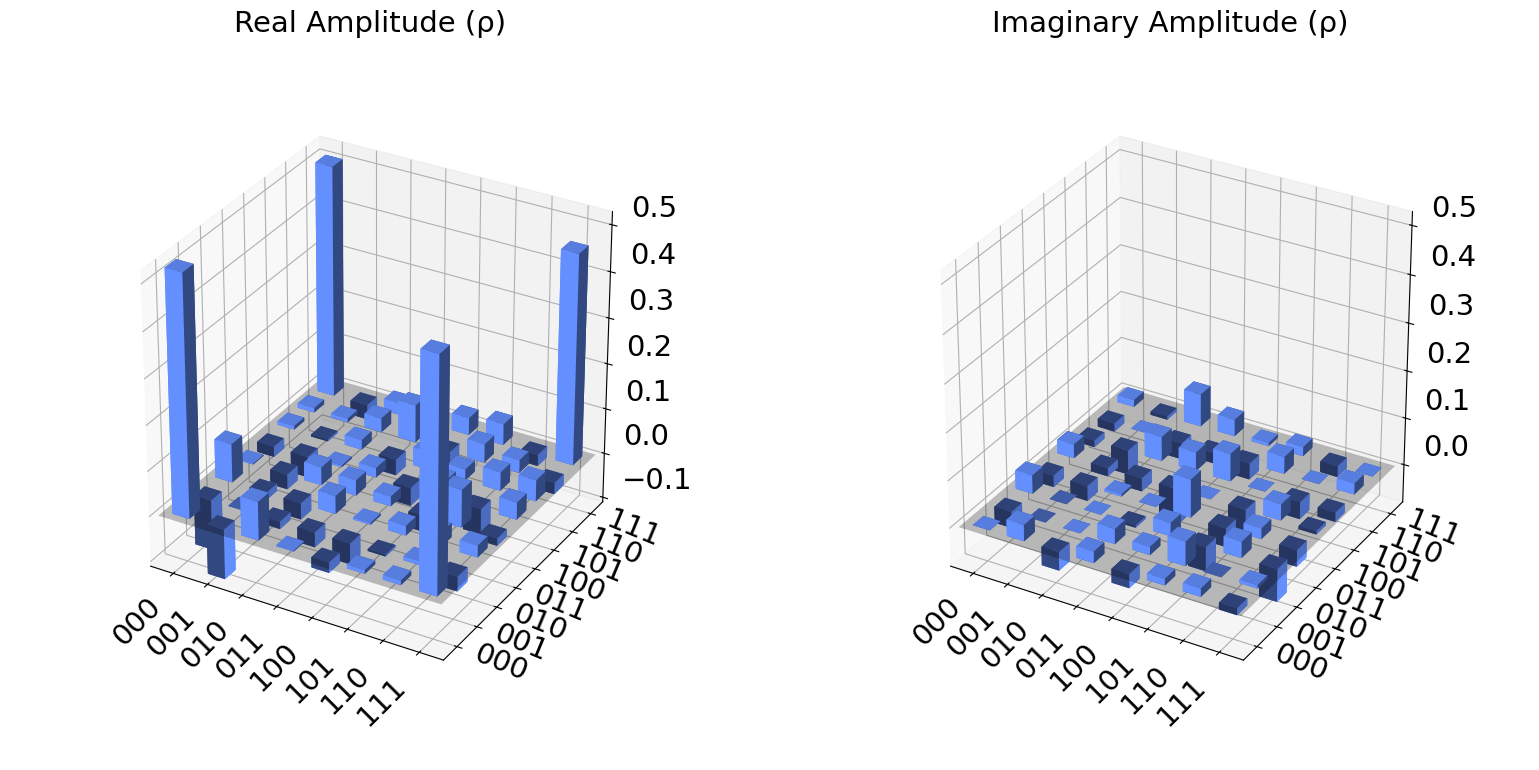

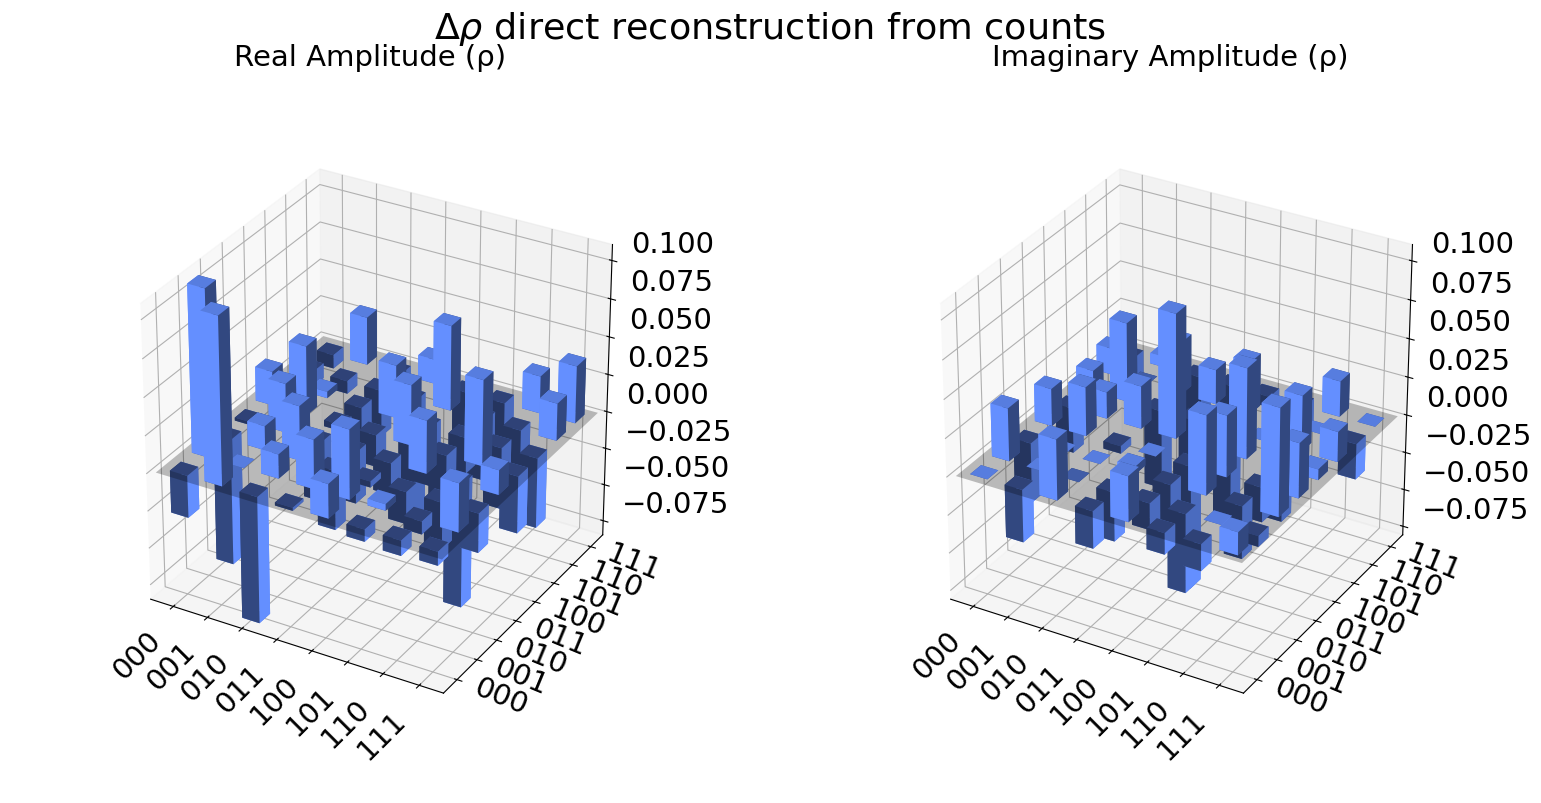

QiskitError: 'Input quantum state is not a valid'

In [21]:
# reconstruct density matrix direct from p_sample
p_sample = samples_to_empirical_dist(samples, N)
povm_dict = build_povm(N)
P_vec    = pvec_from_pdict(p_sample, N)
T, T_inv = get_overlap_matrix(N)
rho_sample = reconstruct_rho(P_vec, N, T_inv, povm_dict)

# verify reconstructed rho
validate_rho(rho_sample)

fig = plot_state_city(rho_sample)
display(fig)

rho_diff = rho_true - rho_sample

fig = plot_state_city(rho_diff, title="$\\Delta\\rho$ direct reconstruction from counts")
display(fig)

fq = quantum_fidelity(rho_true, rho_sample)
print(f"quantum fidelity F_q = {fq:.6f}")

Direct reconstruction leads to un-physical solution.
Need to costraint the possible density matrix to be hermitian, semi-pos

 ## Maximum Likelihood Estimator

In [27]:
# compute density matrix using MLE

# Negative LogLikelihood
nll = make_nll(samples, N)


# creates cholesky params array to initialize minuit
dim = 2**N
init_rho = np.eye(dim, dtype=complex) / dim   # max mixed state
p0 = rho_to_params(init_rho, N)
print(f"Cholesky params to minimize: {count_params(N)}  (= (2^N)^2 )")
print(len(p0), dim**2)


# create Minuit obj
m = Minuit(nll, *p0)
# iminuit built-in to use custom likelihood cost func --> for error estimation m.minos
m.errordef = Minuit.LIKELIHOOD   # = 0.5    
m.print_level = 0

m.migrad()                  
if not m.valid:
    print('not valid!')
    # second try
    m.migrad()
else:
    print('minimization completed!')  
print(f"\nMinuit valid:  {m.valid}")
          


Cholesky params to minimize: 64  (= (2^N)^2 )
64 64
minimization completed!

Minuit valid:  True


  Hermitian:          True
  Tr(rho):            1.00000000
  Pos semi-definite:  True  (min eigval = 2.80e-11)


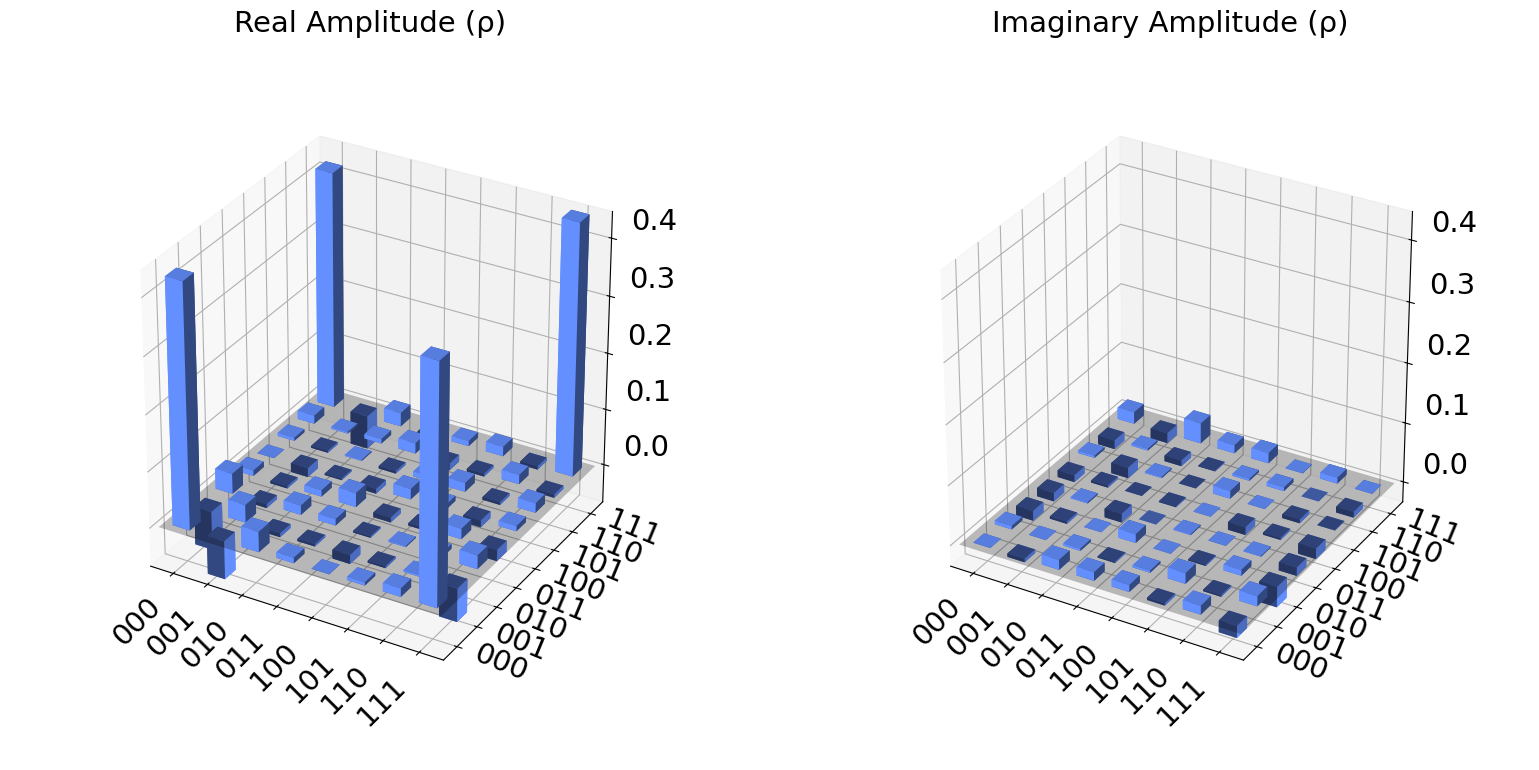

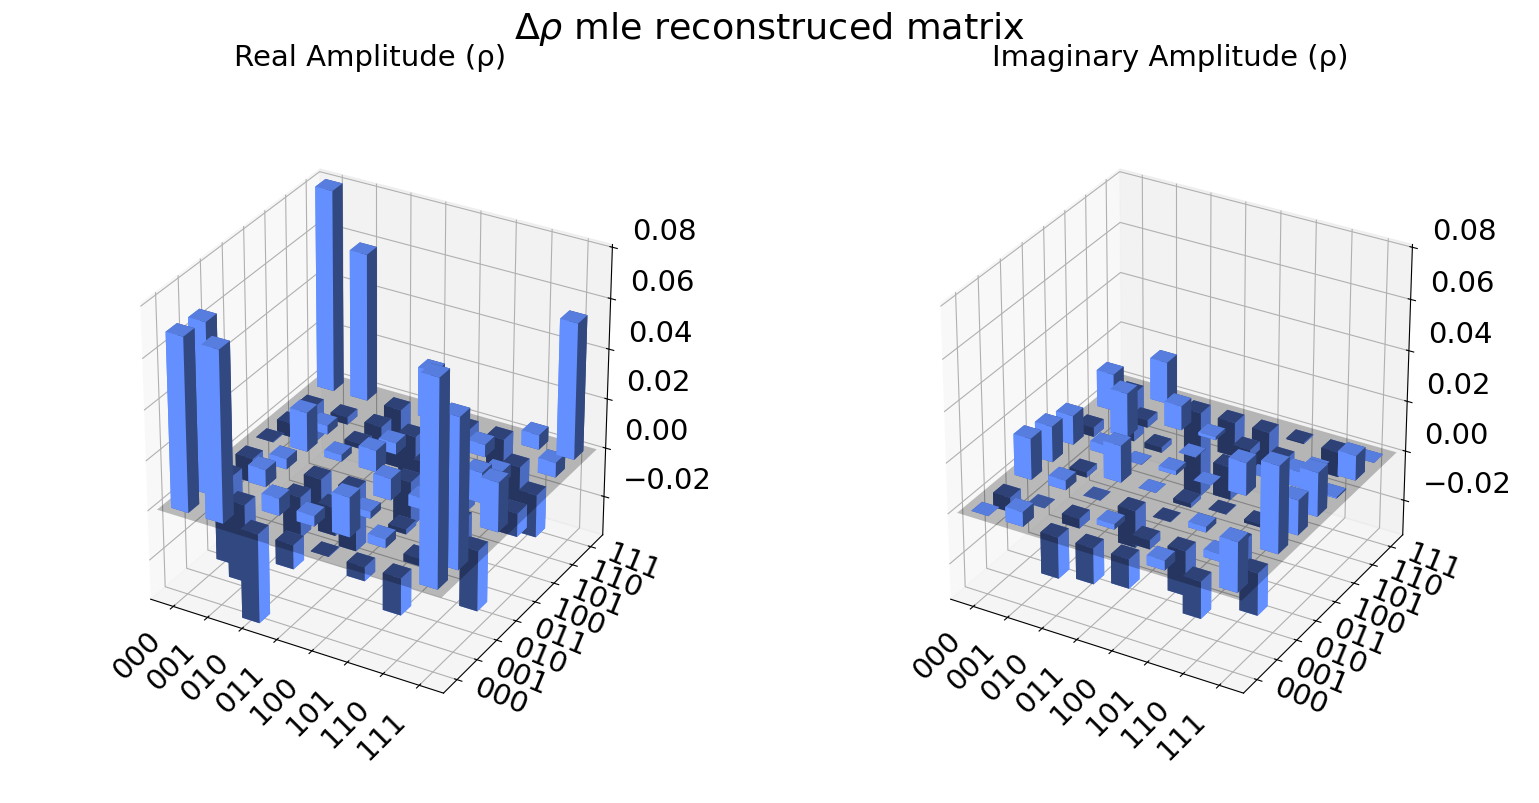

In [28]:
# reconstruct matrix after minimization:
rho_mle = params_to_rho(np.array(m.values), N)

validate_rho(rho_mle)

fig = plot_state_city(rho_mle)
display(fig)

rho_diff = rho_true - rho_mle

fig = plot_state_city(rho_diff, title="$\\Delta\\rho$ mle reconstruced matrix")
display(fig)

In [30]:
# fidelity --> they are from utils.py
fq = quantum_fidelity(rho_true, rho_mle)
print(f"quantum fidelity F_q = {fq:.6f}")

# classical fidelity
p_sample = samples_to_empirical_dist(samples, N)
fc    = classical_fidelity(p_exact, p_sample)
print(f"classical fidelity (sample)  F_c  = {fc:.6f}")

prob_mle = povm_probability(rho_mle, N)
sample_from_rho_mle = sample_povm(prob_mle, 1000)
p_mle = samples_to_empirical_dist(sample_from_rho_mle, N)
fc    = classical_fidelity(p_exact, p_mle)
print(f"classical fidelity (mle)  F_c  = {fc:.6f}")

quantum fidelity F_q = 0.857054
classical fidelity (sample)  F_c  = 0.988477
classical fidelity (mle)  F_c  = 0.981053
